# exploring and inspecting Open Forest Observatory ground-based tree plot survey data

Notes:
- some lat/lon are flipped; correcting via assessment of lat<-90
- plot size ranges from <0.2 Ha  to ~4 Ha
- one plot has abnormally high basal area, 1400 compared to otherwise 10-200ish
- 3 trees have dbh > 5m; one has dbh 22m; possible, but huge. Are these correct or data entry errors?

Open Questions:
- what to predict? species composition/basal area/tree size classes
- 'big tree finding' could be interesting and specific: binary detection of trees with dbh > 2 or 3 m

In [162]:
import polars as pl
import geopandas as gpd
import pandas as pd
import contextily as ctx
# retina plotting
%config InlineBackend.figure_format = 'retina'
from matplotlib import pyplot as plt

In [164]:
# tree species: downloaded from usfs v9-5 species list https://usfs-public.app.box.com/v/FIA-TreeSpeciesList/file/1681734489186
# linked from https://research.fs.usda.gov/programs/fia/forestdefinitions

In [165]:
plots = gpd.read_file('../datasets/raw/OFO_trees/ofo_ground-reference_plots.gpkg')
trees = gpd.read_file('../datasets/raw/OFO_trees/ofo_ground-reference_trees.gpkg')
# convert dbh from cm to m
trees['dbh'] = trees['dbh'] / 100

In [166]:
tree_sp = pd.read_excel('../datasets/raw/OFO_trees/v9-5_2024-10_FIATreeList.xlsx')
code_to_common = tree_sp.set_index('PLANTS Code')['Common Name'].to_dict()
code_to_common

{'ABAM': 'Pacific silver fir',
 'ABBA': 'balsam fir',
 'ABBR': 'Santa Lucia or bristlecone fir',
 'ABCO': 'white fir',
 'ABFR': 'Fraser fir',
 'ABGR': 'grand fir',
 'ABLAA': 'corkbark fir',
 'ABLA': 'subalpine fir',
 'ABMA': 'California red fir',
 'ABSH': 'Shasta red fir',
 'ABPR': 'noble fir',
 'CHLA': 'Port-Orford-cedar',
 'CHNO': 'Alaska yellow-cedar',
 'CHTH2': 'Atlantic white-cedar',
 'CUAR': 'Arizona cypress',
 'CUBA': 'Baker or Modoc cypress',
 'CUFO2': 'Tecate cypress',
 'CUMA2': 'Monterey cypress',
 'CUSA3': "Sargent's cypress",
 'CUMA': "MacNab's cypress",
 'JUPI': 'Pinchot juniper',
 'JUCO11': 'redberry juniper',
 'JUFL': 'Drooping juniper',
 'JUAS': 'Ashe juniper',
 'JUCA7': 'California juniper',
 'JUDE2': 'alligator juniper',
 'JUOC': 'western juniper',
 'JUOS': 'Utah juniper',
 'JUSC2': 'Rocky Mountain juniper',
 'JUVIS': 'southern redcedar',
 'JUVI': 'eastern redcedar',
 'JUMO': 'oneseed juniper',
 'LARIX': 'larch spp.',
 'LALA': 'tamarack',
 'LALY': 'subalpine larch',
 

In [167]:
# some plots have swapped lat/lon!
def is_swapped(row):
    if row['plot_lat']<-90:
        return True
    return False

new_latlon = [(row['plot_lon'], row['plot_lat']) if is_swapped(row) else (row['plot_lat'], row['plot_lon']) for i, row in plots.iterrows()]
plots['plot_lat'] = [lat for lat, lon in new_latlon]
plots['plot_lon'] = [lon for lat, lon in new_latlon]

<Axes: xlabel='height_mean', ylabel='height_std'>

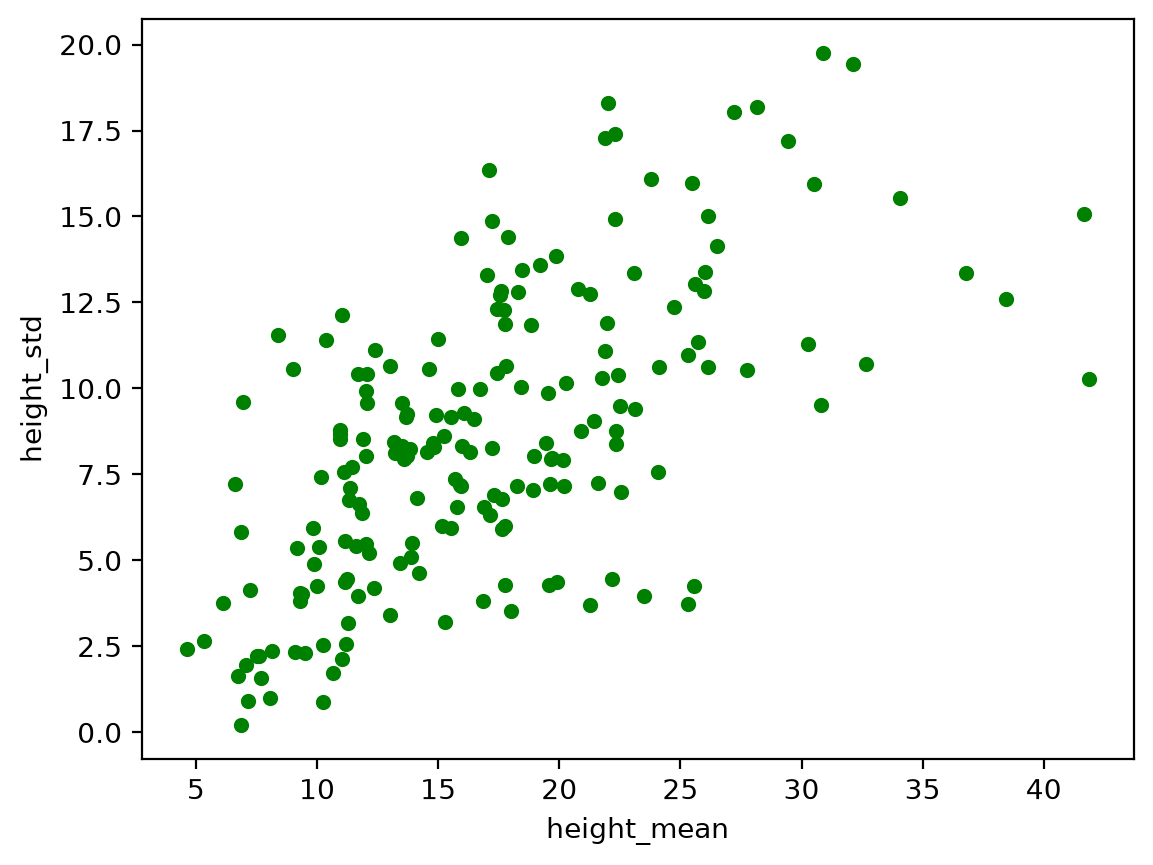

In [168]:
tree_ht_distr_perplot = trees.groupby('plot_id')['height'].agg(['mean', 'std', 'count']).reset_index().rename(columns={'mean':'height_mean', 'std':'height_std', 'count':'height_count'})
tree_ht_distr_perplot.plot(x='height_mean', y='height_std', kind='scatter', color='green', s=20)

<Axes: >

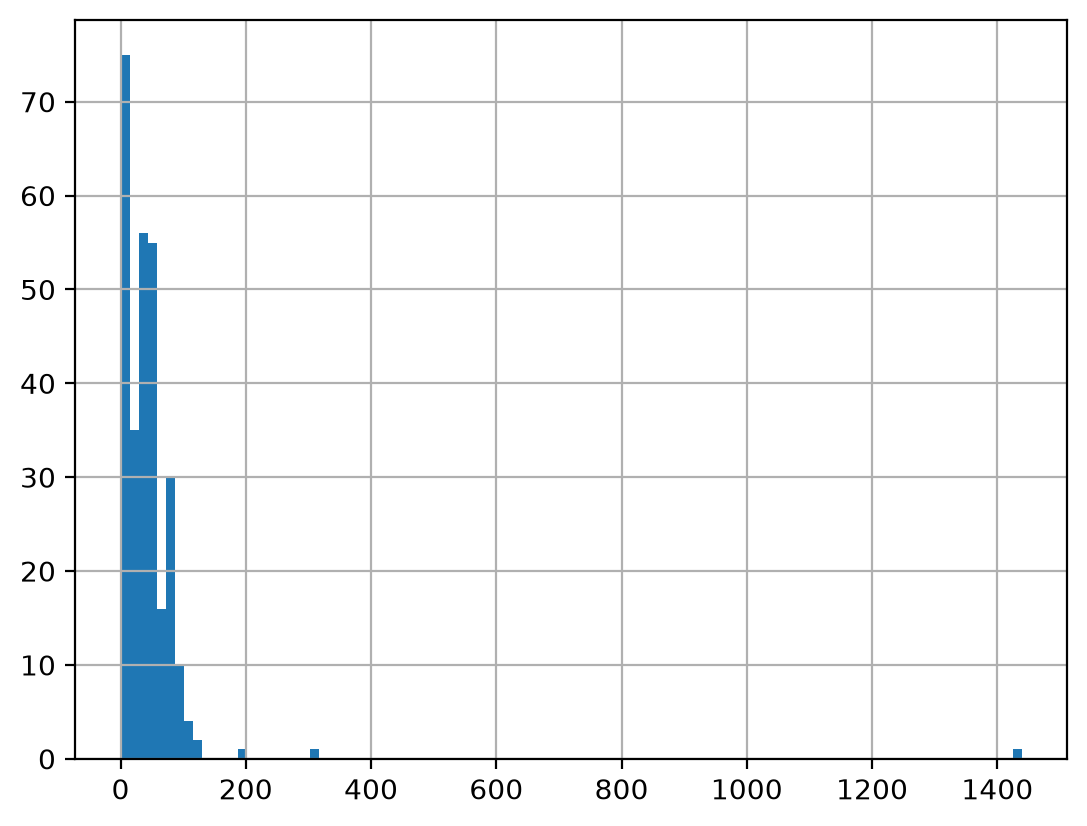

In [178]:
# calculate basal area per plot
trees['basal_area'] = 3.14159 * (trees['dbh']/2)**2
basal_area_per_plot = trees.groupby('plot_id')['basal_area'].sum().rename('basal_area_sum')#.reset_index()
plots['basal_area_m2ha']=plots.join(basal_area_per_plot, on='plot_id')['basal_area_sum'] / plots['plot_area_ha']
# basal_area_per_plot
plots['basal_area_m2ha'].hist(bins=100)

In [205]:
plot_sp_counts = trees.groupby(['plot_id','species_code']).size().unstack()
plot_sp_proportions = plot_sp_counts.div(plot_sp_counts.sum(axis=1), axis=0)
# dictionary of sp:proportion for top 5 sp in each plot
top_sp_per_plot = plot_sp_counts.apply(lambda x: x.nlargest(5).dropna().round(2).to_dict(), axis=1)
top_sp_per_plot

plot_id
0001    {'ABCO': 44.0, 'CADE27': 8.0, 'PSME': 7.0, 'PI...
0002    {'ABCO': 81.0, 'CADE27': 20.0, 'QUKE': 9.0, 'P...
0003    {'PSME': 73.0, 'NODE3': 22.0, 'PIPO': 16.0, 'A...
0004          {'ABMA': 166.0, 'PICO': 10.0, 'PIMO3': 5.0}
0005          {'ABMA': 126.0, 'PIMO3': 26.0, 'ABCO': 1.0}
                              ...                        
0291                        {'PSME': 379.0, 'ACMA3': 3.0}
0292    {'CADE27': 80.0, 'PIPJ': 75.0, 'UNK or UNCL': ...
0293    {'ABCO': 19.0, 'UNK or UNCL': 18.0, 'PILA': 12...
0294    {'ABCO': 27.0, 'CADE27': 15.0, 'PIPJ': 12.0, '...
0295    {'UNK or UNCL': 56.0, 'CADE27': 28.0, 'ABCO': ...
Length: 286, dtype: object

<Axes: >

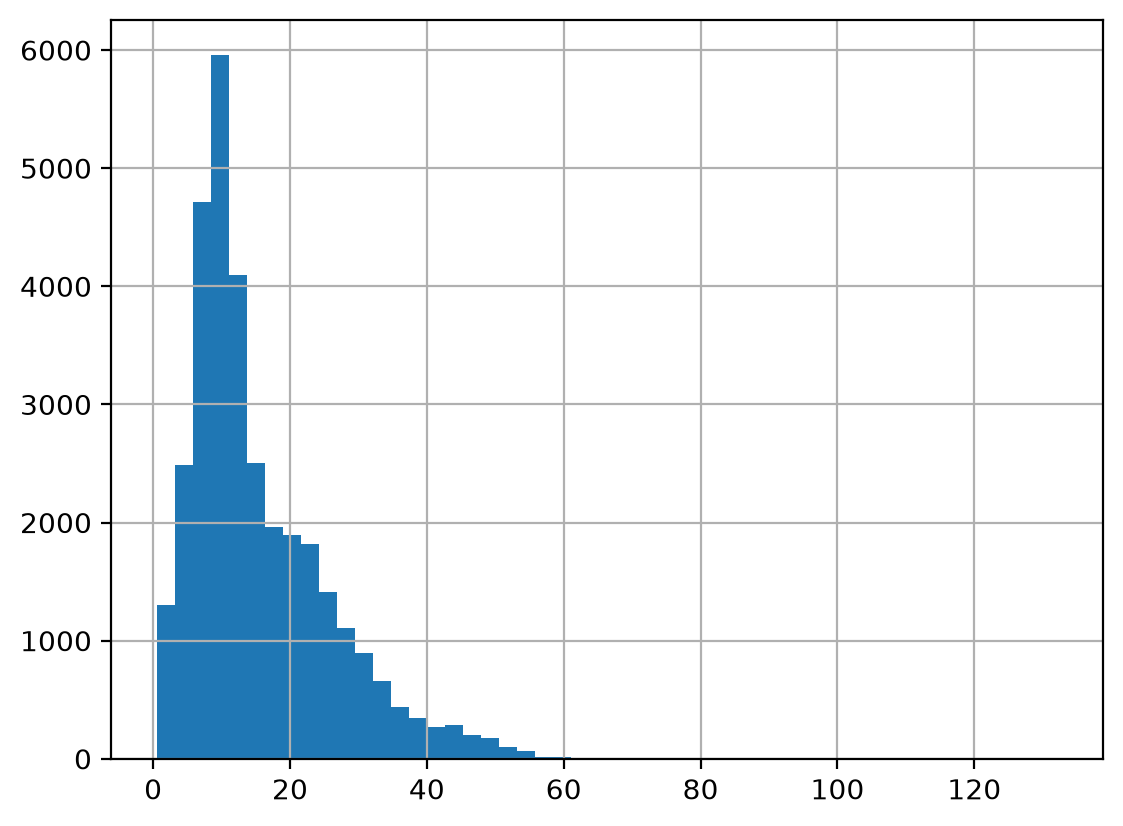

In [ ]:
trees.height.hist(bins=50)

In [223]:
# proportion of missing data per column
trees.notnull().mean().sort_values(ascending=False).round(2)

plot_id                         1.00
species_code                    1.00
geometry                        1.00
growth_form                     1.00
live_dead                       0.98
basal_area                      0.96
dbh                             0.96
contributor_tree_id             0.93
height                          0.51
crown_position                  0.33
ohvis                           0.33
subplot_id                      0.17
crown_ratio_compacted           0.15
damage_1                        0.09
decay_class                     0.07
height_allometric               0.05
damage_2                        0.03
precent_postfire_crown_green    0.03
height_to_crown                 0.03
height_to_needle                0.03
crown_width_1                   0.02
percent_prefire_crown_green     0.02
crown_width_allometric          0.02
scorch_height                   0.02
crown_width_2                   0.01
damage_3                        0.00
crown_ratio                     0.00
d

In [227]:
import numpy as np
oneplot = trees[trees.plot_id==np.random.choice(trees.plot_id.unique())]
print(oneplot.shape)
oneplot.head(5).T


(149, 31)


,4492,4493,4494,4495,4496
plot_id,0027,0027,0027,0027,0027
subplot_id,NaN,NaN,NaN,NaN,NaN
height,14.3256,11.5824,10.3632,34.1376,10.668
height_allometric,NaN,NaN,NaN,NaN,NaN
height_above_plot_center,NaN,NaN,NaN,NaN,NaN
dbh,0.3302,0.23622,0.22606,1.09728,0.24638
species_code,ABCO,ABCO,ABCO,PIJE,ABCO
growth_form,tree,tree,tree,tree,tree
live_dead,L,L,L,L,L
crown_position,3.0,4.0,4.0,2.0,3.0


<Axes: xlabel='proportion', ylabel='common_name'>

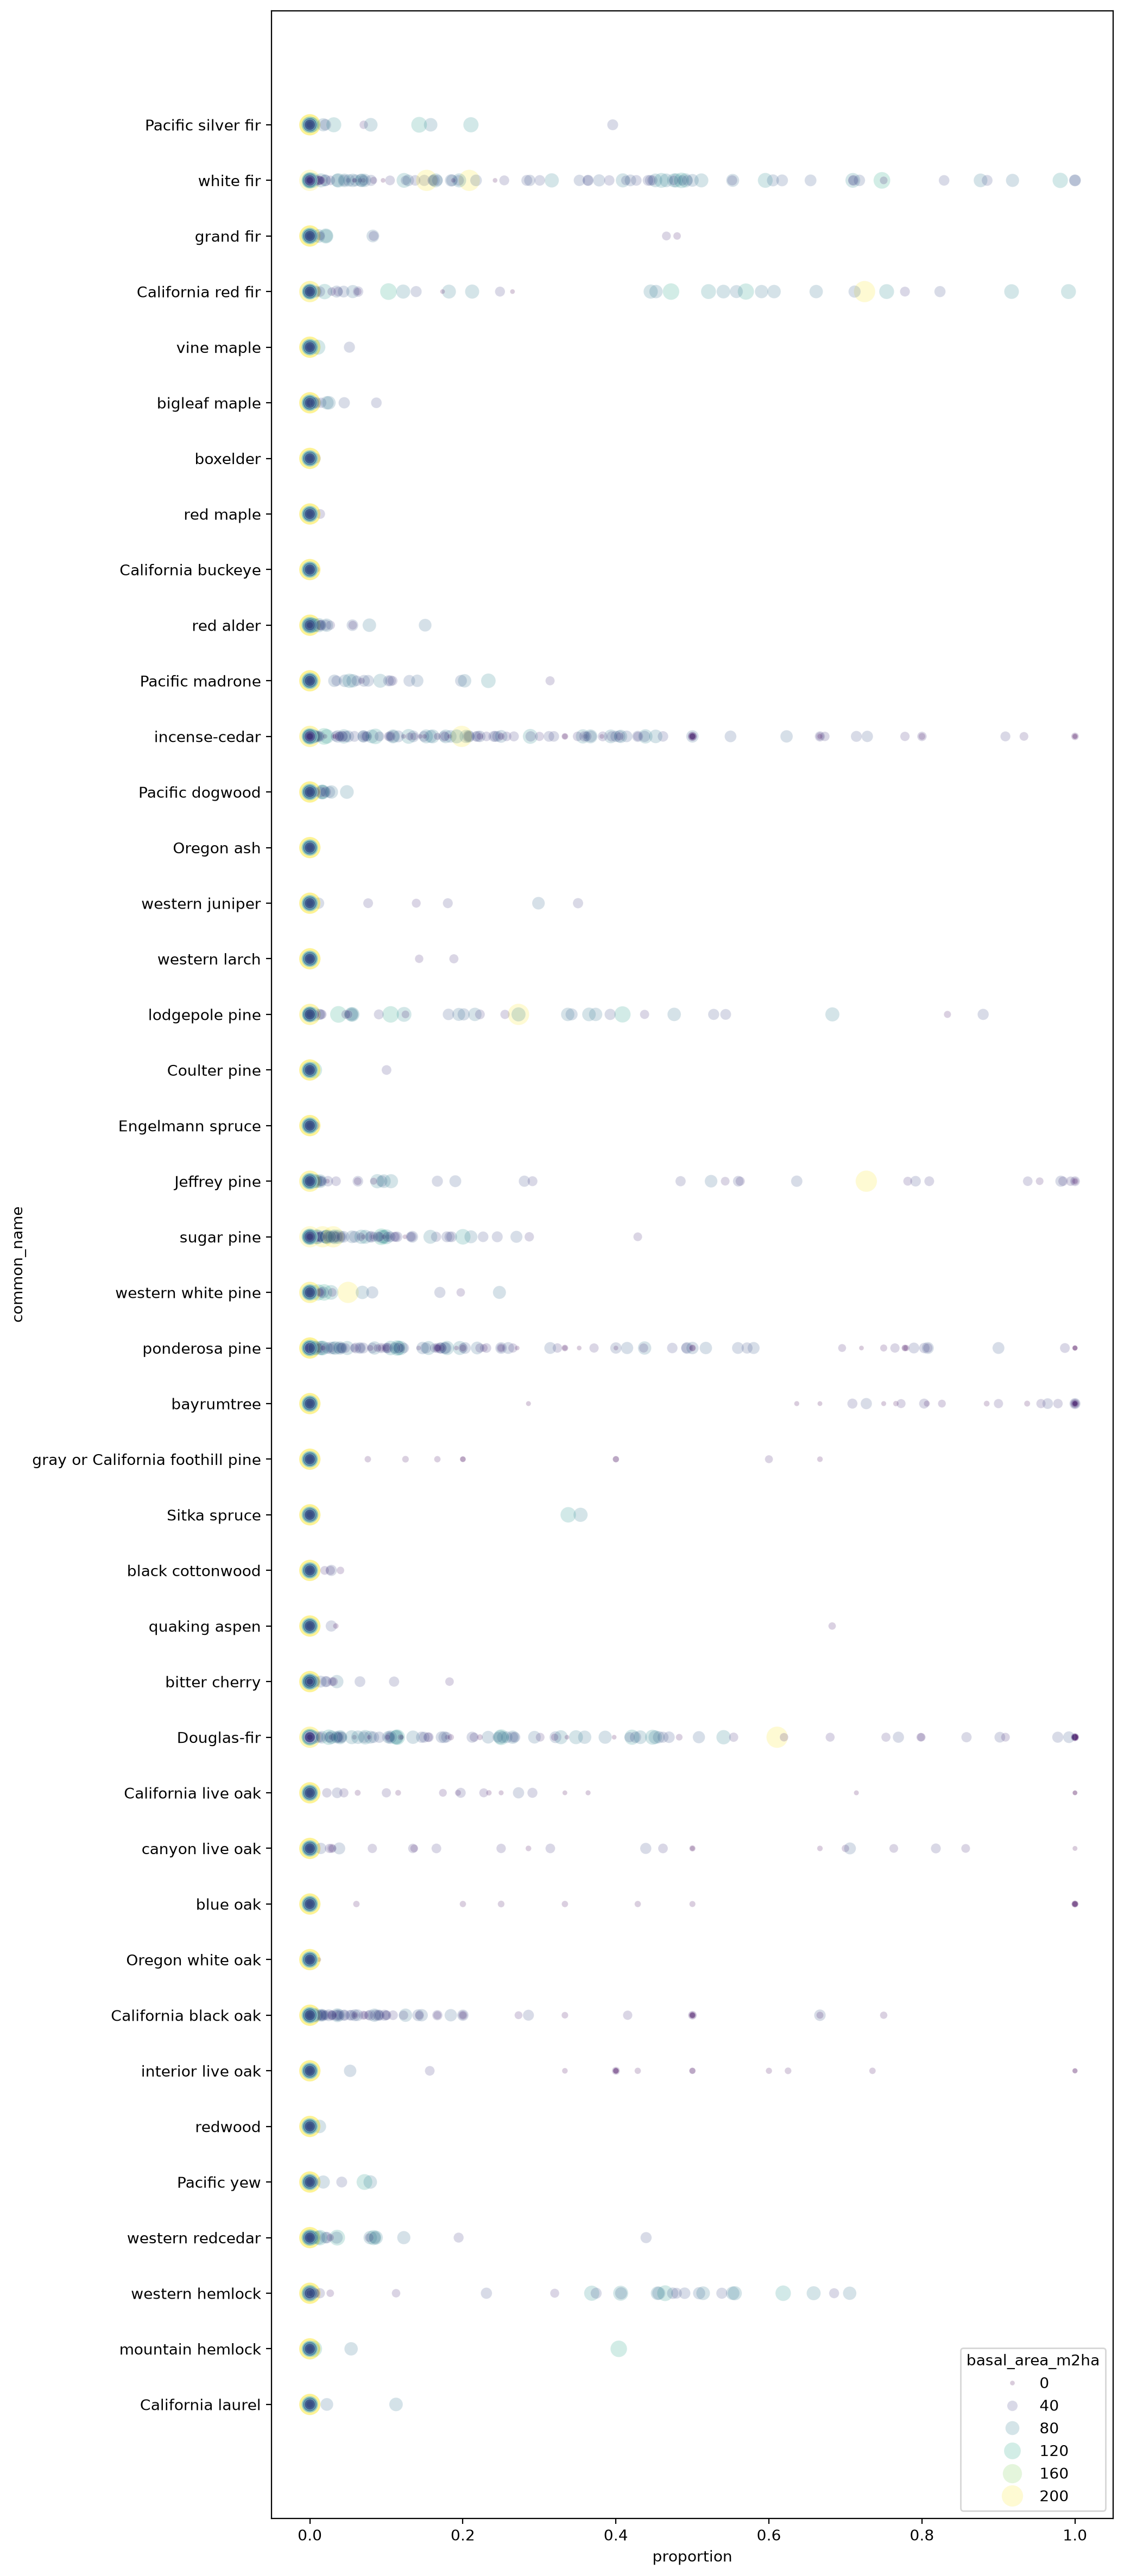

In [181]:
# visualize plot_sp_proportions: one row per sp
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 30))
# add mean plot dbh
records=plot_sp_proportions.reset_index().melt(id_vars='plot_id', var_name='species_code', value_name='proportion').fillna(0)
records['common_name']=records['species_code'].map(code_to_common)
records=records.join(plots.set_index('plot_id')['basal_area_m2ha'].clip(0,200), on='plot_id')

sns.scatterplot(data=records, x='proportion', y='common_name',alpha=0.2,ax=ax, hue='basal_area_m2ha', palette='viridis', size='basal_area_m2ha', sizes=(10, 200))
# records

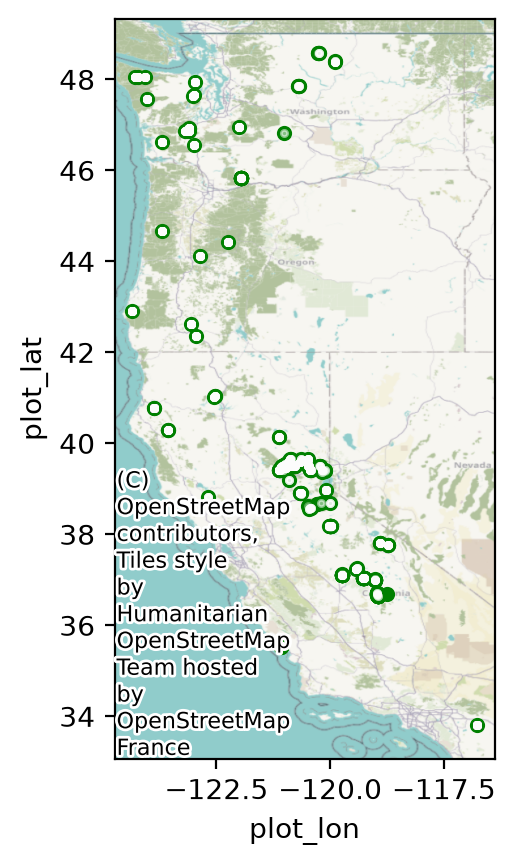

In [182]:
ax=plots.plot(x='plot_lon', y='plot_lat', kind='scatter',color='green')
trees.sample(3000).plot(alpha=0.3,markersize=5,ax=ax,color='white')

ctx.add_basemap(ax, crs=plots.crs.to_string())
# equal axes no stretching
ax.set_aspect('equal')

In [183]:
# look at this one: does it actually have a tree with 22m dbh? or is it data entry error?

In [184]:
trees[trees['plot_id']==large_ba_plot].dbh.describe()

count    33.000000
mean      1.083887
std       3.938401
min       0.124460
25%       0.162560
50%       0.241300
75%       0.734060
max      22.961600
Name: dbh, dtype: float64

In [185]:
trees.groupby('plot_id')['dbh'].mean().describe()

count    276.000000
mean       0.327480
std        0.154947
min        0.029667
25%        0.245983
50%        0.311844
75%        0.382691
max        1.083887
Name: dbh, dtype: float64

In [186]:
trees[trees.dbh>5]

,plot_id,subplot_id,height,height_allometric,height_above_plot_center,dbh,species_code,growth_form,live_dead,crown_position,...,decay_class,damage_1,damage_2,damage_3,damage_4,damage_5,contributor_tree_id,notes,geometry,basal_area
334,0018,NaN,7.6200,NaN,NaN,22.9616,PIJE,tree,L,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,POINT (-120.17653 39.40565),414.089109
3890,0006,NaN,29.8704,NaN,NaN,6.8580,ABMA,tree,L,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-120.66953 39.59384),36.938944
46375,0108,NaN,41.1480,NaN,NaN,8.9408,PSME,tree,L,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,95,NaN,POINT (-120.95062 39.49504),62.783030


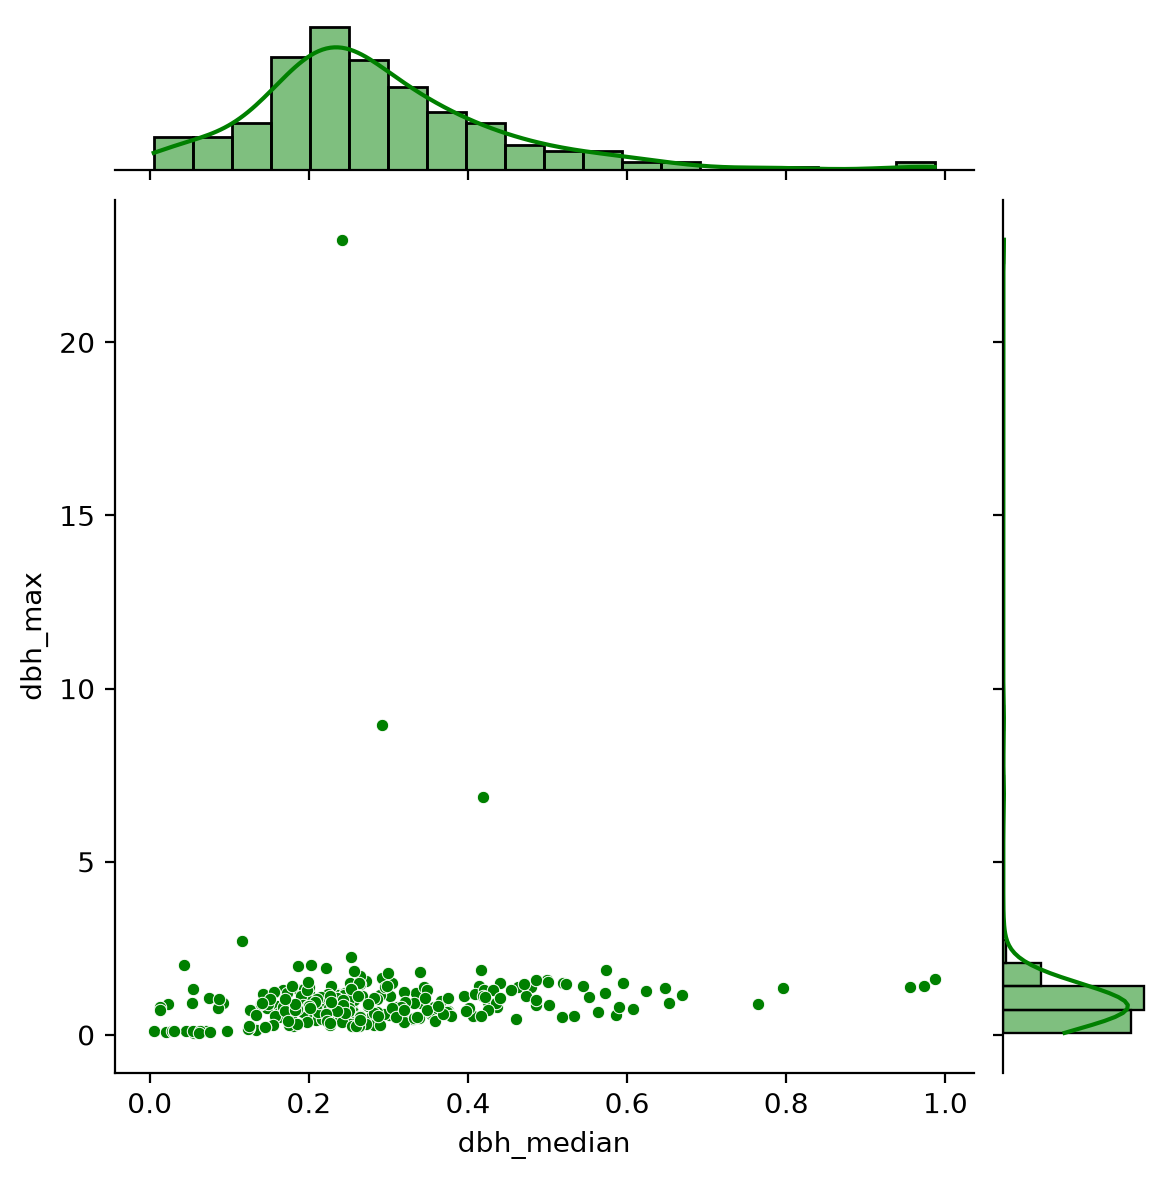

In [187]:
tree_dbh_distr_perplot = trees.groupby('plot_id')['dbh'].agg(['median', 'std', 'count','max']).reset_index().rename(columns={'median':'dbh_median', 'std':'dbh_std', 'count':'dbh_count', 'max':'dbh_max'})
# tree_dbh_distr_perplot.plot(x='dbh_mean', y='dbh_std', kind='scatter', color='green', s=20)

sns.jointplot(data=tree_dbh_distr_perplot, x='dbh_median', y='dbh_max', kind='scatter', color='green', s=20,marginal_kws=dict(kde=True),  )

In [188]:
# binary classification of plots having trees over a specific dbh threshold:
{d:(tree_dbh_distr_perplot['dbh_max']>d).mean().round(3) for d in (1,1.5, 2,2.5, 3,4)}

{1: np.float64(0.36),
 1.5: np.float64(0.091),
 2: np.float64(0.024),
 2.5: np.float64(0.014),
 3: np.float64(0.01),
 4: np.float64(0.01)}

<Axes: xlabel='basal_area_m2ha', ylabel='Count'>

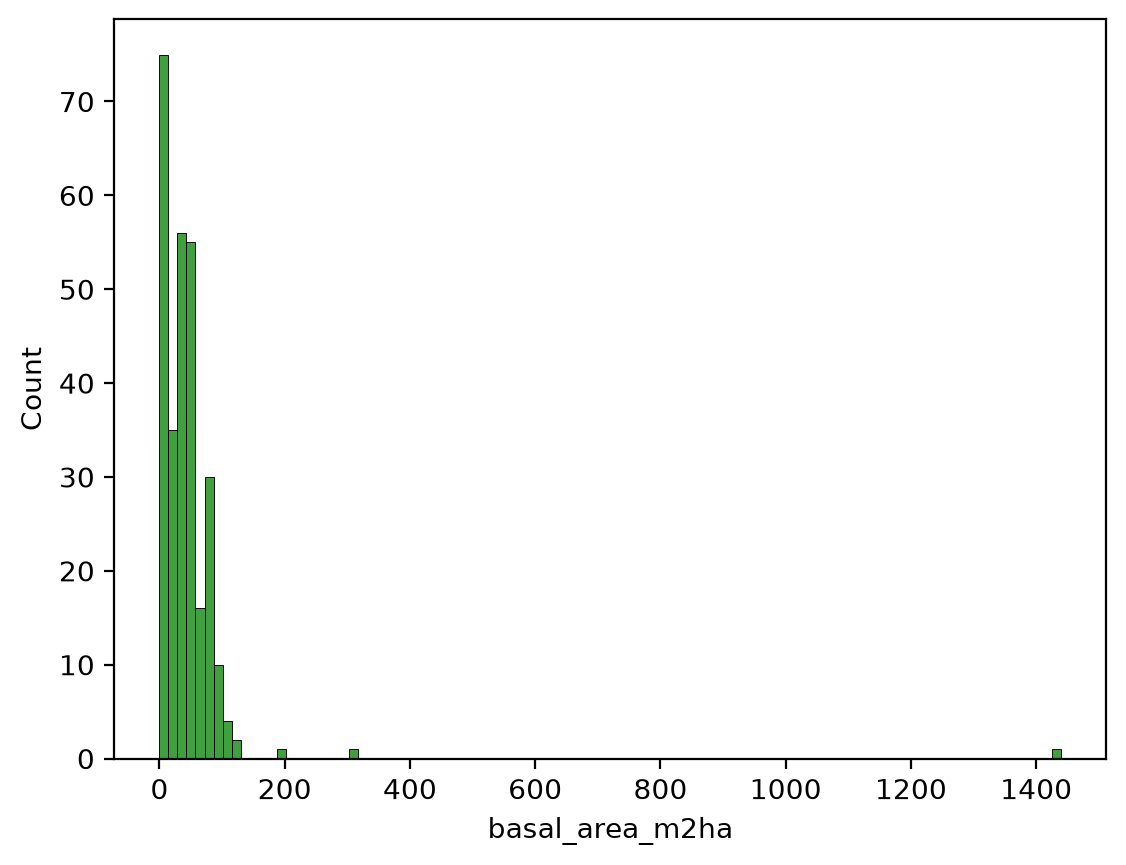

In [189]:
sns.histplot(data=plots, x='basal_area_m2ha', bins=100, color='green')

<Axes: xlabel='plot_area_ha', ylabel='Density'>

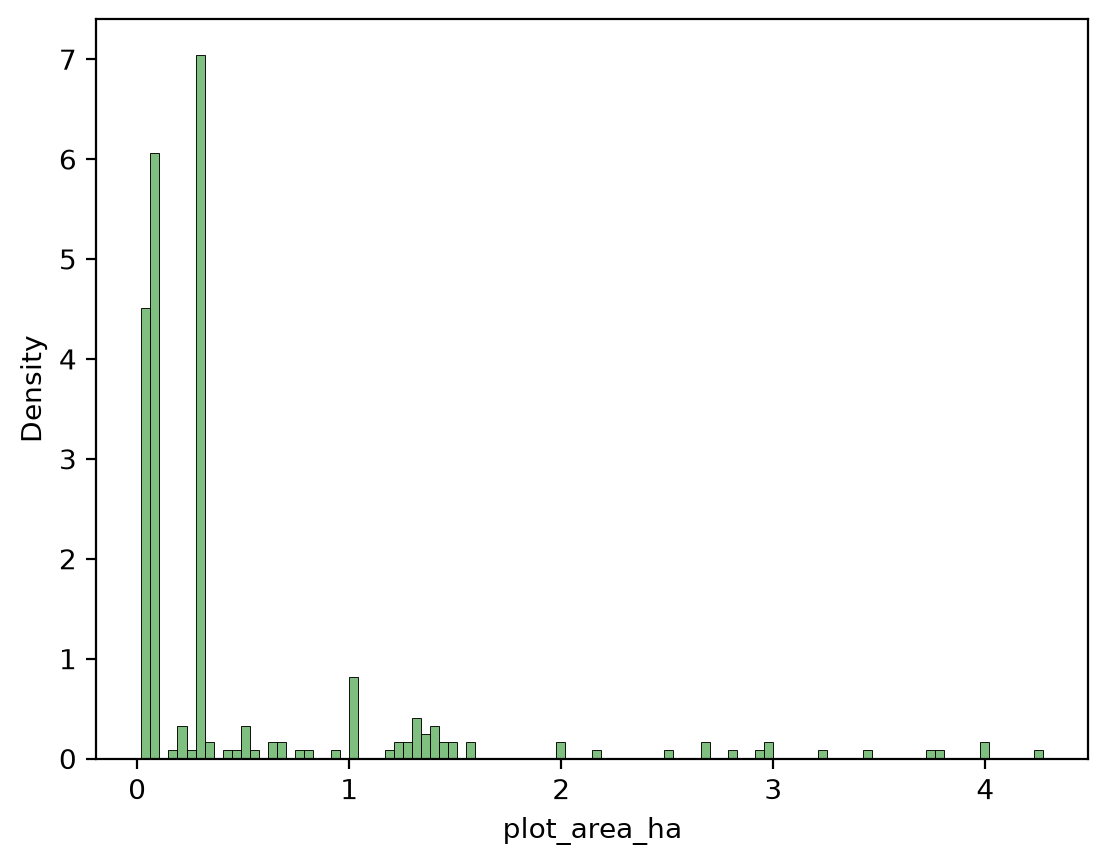

In [190]:
sns.histplot(data=plots, x='plot_area_ha', bins=100, color='green', alpha=0.5, stat='density')

<Axes: >

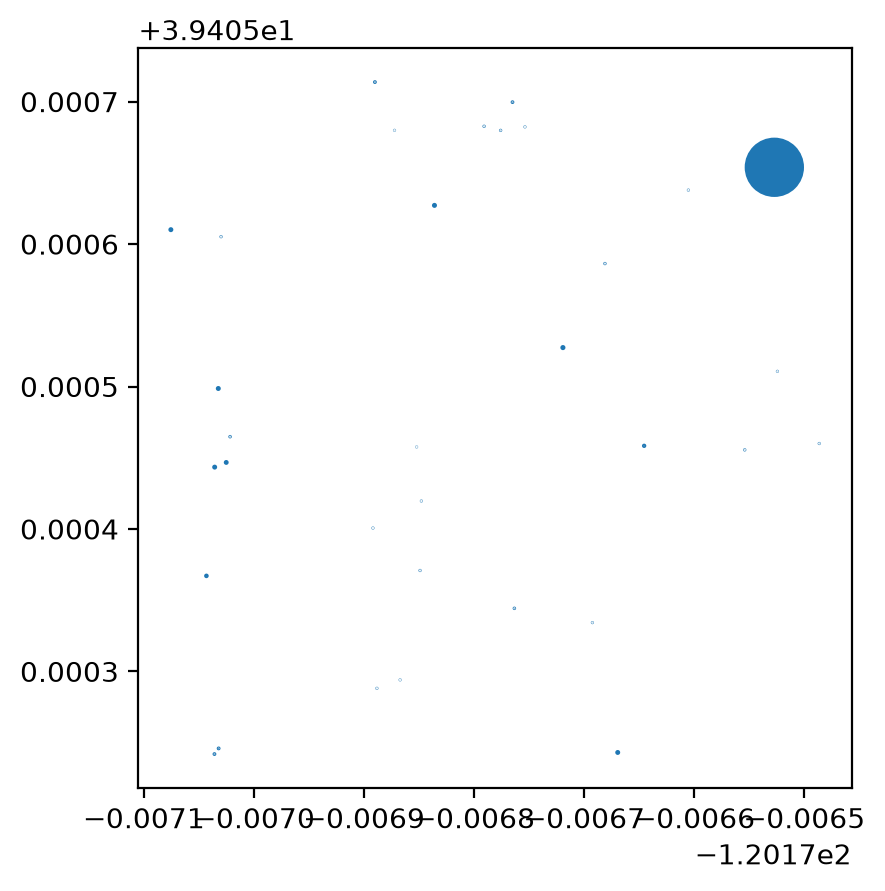

In [191]:
large_ba_plot = plots[plots['basal_area_m2ha']>1000]['plot_id'].iloc[0]
trees[trees['plot_id']==large_ba_plot].plot(markersize='basal_area')

# check lidar availability per plot

In [192]:
import sys
sys.path.append('../src/streaming/3dep/')
from get_als import get_nearest_year_product

In [193]:
plots['survey_year']=plots['survey_date'].astype('str').str[:4].astype('int')
plots['survey_year'].value_counts().sort_index()

survey_year
2007     1
2008     2
2013     6
2014     1
2015    42
2016     4
2017    14
2018    16
2019     8
2020     8
2021    50
2022    91
2023    40
2025     4
Name: count, dtype: int64

In [194]:
def find(row):
    try:
        result = get_nearest_year_product(row['plot_lat'], row['plot_lon'], row['survey_year'])
        assert result is not None, "No product found"
        return result
    except Exception as e:
        return {'product_name_AWS': None, 'collection_year_AWS': None, 'year_diff_AWS': None}

In [195]:
vals= plots.apply(find, axis=1, result_type='expand')
plots=plots.join(vals,how='left')

In [196]:
# 10% of plots no als data

In [197]:
plots.year_diff_AWS.isna().mean()

np.float64(0.0975609756097561)

In [198]:
# 68% of plots have ALS data within 3 years of survey year

In [199]:
(plots.year_diff_AWS.fillna(100)<=3).mean()

np.float64(0.686411149825784)

In [159]:
# when we decide what to predict on each plot, add those aggregated values into the table and re-run this notebook

In [201]:
plots_w_als

,plot_id,project_id,project_name,investigator_names,investigator_contacts,license_short,license,hyperplot_id,survey_date_approx,survey_date,...,plot_lat,num_ohvis_trees_excluded,contributor_plot_id,test_split,geometry,basal_area_m2ha,survey_year,product_name_AWS,collection_year_AWS,year_diff_AWS
1,0081,8.0,SJGEO2018,Dr. Marko Spasojevic,markos@ucr.edu,CC BY 4.0,"CC BY 4.0; Spasojevic, Marko et al. (2023). Da...",NaN,True,201910.0,...,33.810270,NaN,NaN,False,"POLYGON ((-116.76897 33.81007, -116.76767 33.8...",33.422133,2019,USGS_LPC_CA_SoCal_Wildfires_B1_2018_LAS_2019,2019.0,0.0
2,0084,9.0,JLHZ2019,"James Lamping, Harold Zald","jlamping@uoregon.edu, Harold.Zald@usda.gov",CC BY 4.0,CC BY 4.0,NaN,True,201907.0,...,37.099000,NaN,OW2,False,"MULTIPOLYGON (((-119.73617 37.09988, -119.7361...",9.032999,2019,CA_FEMAR9Fresno_2_2019,2019.0,0.0
6,0068,5.0,EP2018,"JonahMaria Weeks, Dr. Derek Young, Dr. Hugh Sa...","jsweeks@ucdavis.edu, djyoung@ucdavis.edu; hdsa...",CC BY 4.0,CC BY 4.0,NaN,True,20190915.0,...,38.966555,NaN,NaN,True,"POLYGON ((-120.08843 38.96572, -120.08844 38.9...",84.094234,2019,CA_SierraNevada_5_2022,2021.0,2.0
7,0074,7.0,STEF2018,Alexis Bernal,alexis_bernal@berkeley.edu,Public domain,These data were collected using funding from t...,NaN,True,2018.0,...,38.174167,NaN,Unit 5,False,"POLYGON ((-120.00371 38.17453, -120.00487 38.1...",41.044790,2018,CA_SierraNevada_12_B22,2021.0,3.0
8,0073,7.0,STEF2018,Alexis Bernal,alexis_bernal@berkeley.edu,Public domain,These data were collected using funding from t...,NaN,True,2018.0,...,38.172259,NaN,Unit 2,False,"POLYGON ((-120.0064 38.1715, -120.00722 38.170...",43.841575,2018,CA_SierraNevada_12_B22,2021.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,0251,19.0,Cambria2021,"Dr. Sarah Bisbing, Conor Phelan","sbisbing@unr.edu, cphelan@unr.edu",CC BY 4.0,CC BY 4.0,0010,True,20210120.0,...,35.537974,NaN,RM19_small,False,"POLYGON ((-121.07927 35.53799, -121.07927 35.5...",1.510350,2021,CA_FEMA_Z4_B2_2018,2018.0,3.0
283,0252,19.0,Cambria2021,"Dr. Sarah Bisbing, Conor Phelan","sbisbing@unr.edu, cphelan@unr.edu",CC BY 4.0,CC BY 4.0,0011,True,20210126.0,...,35.537675,NaN,RM20_small,False,"POLYGON ((-121.07569 35.53769, -121.07569 35.5...",0.150156,2021,CA_FEMA_Z4_B2_2018,2018.0,3.0
284,0253,19.0,Cambria2021,"Dr. Sarah Bisbing, Conor Phelan","sbisbing@unr.edu, cphelan@unr.edu",CC BY 4.0,CC BY 4.0,0012,True,20210115.0,...,35.538642,NaN,RM21_small,False,"POLYGON ((-121.08226 35.53866, -121.08226 35.5...",6.164057,2021,CA_FEMA_Z4_B2_2018,2018.0,3.0
285,0254,19.0,Cambria2021,"Dr. Sarah Bisbing, Conor Phelan","sbisbing@unr.edu, cphelan@unr.edu",CC BY 4.0,CC BY 4.0,0013,True,20210119.0,...,35.539659,NaN,RM22_small,False,"POLYGON ((-121.08025 35.53968, -121.08025 35.5...",3.486560,2021,CA_FEMA_Z4_B2_2018,2018.0,3.0


In [200]:
plots_w_als = plots[plots.year_diff_AWS.fillna(100)<=3]
plots_w_als.rename(columns={'withhold_from_training':'test_split'}, inplace=True)
plots_w_als.to_file('../datasets/OFO_trees/plots_w_als.gpkg')